# Dataset Source
https://www.kaggle.com/datasets/hiimanshuagarwal/predictive-maintenance-dataset

## About
A company has a fleet of devices transmitting daily sensor readings. They would like to create a predictive maintenance solution to proactively identify when maintenance should be performed. This approach promises cost savings over routine or time based preventive maintenance, because tasks are performed only when warranted.

The task is to build a predictive model using machine learning to predict the probability of a device failure. When building this model, be sure to minimize false positives and false negatives. The column you are trying to Predict is called failure with binary value 0 for non-failure and 1 for failure.

## Relation to MaintenaSense
The purpose of the data is similar to the scope of the project and fulfills the baseline requirements:
- Time series
- Variour machines
- Various measures

Still we have to deal with the low representation of the mumber of samples for the faults

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import matplotlib
import scipy
import statsmodels
import imblearn
#import mlxtend
import xgboost
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.metrics import  f1_score, roc_auc_score, precision_recall_curve, auc, accuracy_score, precision_score, recall_score,classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization

#from mlxtend.evaluate.time_series import GroupTimeSeriesSplit,plot_splits,print_cv_info,print_split_info

from visualisations import print_details
from visualisations import analysis_by_metrics
from visualisations import correlation
from visualisations import detailed_assessment
from visualisations import calculations

#from data_split import timeseries_split

from model_test import model_test
from model_test import model_test_weighted

#from datasampling_df import ohit_oversample, ohit_oversample_timeaware, drsnn_oversample

print(f"Pandas: {pd.__version__}")
print(f"Numpy: {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Sklearn: {sklearn.__version__}")
print(f"Scipy: {scipy.__version__}")
print(f"Statsmodels: {statsmodels.__version__}")
print(f"Imblearn: {imblearn.__version__}")
#print(f"mlxtend: {mlxtend.__version__}")
#print(f"xgboost: {xgboost.__version__}")

ModuleNotFoundError: No module named 'pandas'

In [2]:
df = pd.read_csv('datasets/predictive maintenance/predictive_maintenance_dataset.csv')

In [3]:
df_metrics = df[['metric2','metric4','metric7','failure']]
metric_columns = df[['metric2','metric4','metric7']]

### Exploratory Data Analysis (EDA)

In [4]:
print_details(df)

Precdictive Maintenance data:
--------------------------------
Shape: (124494, 12)

Columns: Index(['date', 'device', 'failure', 'metric1', 'metric2', 'metric3', 'metric4',
       'metric5', 'metric6', 'metric7', 'metric8', 'metric9'],
      dtype='object')

Count: failure
0    124388
1       106
Name: count, dtype: int64

Devices: ['S1F01085' 'S1F0166B' 'S1F01E6Y' ... 'S1F02XLX' 'S1F03499' 'W1F1DA5ÿ']

Dates: ['1/1/2015' '1/2/2015' '1/3/2015' '1/4/2015' '1/5/2015' '1/6/2015'
 '1/7/2015' '1/8/2015' '1/9/2015' '1/10/2015' '1/11/2015' '1/12/2015'
 '1/13/2015' '1/14/2015' '1/15/2015' '1/16/2015' '1/17/2015' '1/18/2015'
 '1/19/2015' '1/20/2015' '1/21/2015' '1/22/2015' '1/23/2015' '1/24/2015'
 '1/25/2015' '1/26/2015' '1/27/2015' '1/28/2015' '1/29/2015' '1/30/2015'
 '1/31/2015' '2/1/2015' '2/2/2015' '2/3/2015' '2/4/2015' '2/5/2015'
 '2/6/2015' '2/7/2015' '2/8/2015' '2/9/2015' '2/10/2015' '2/11/2015'
 '2/12/2015' '2/13/2015' '2/14/2015' '2/15/2015' '2/16/2015' '2/17/2015'
 '2/18/2015' '2/19/2

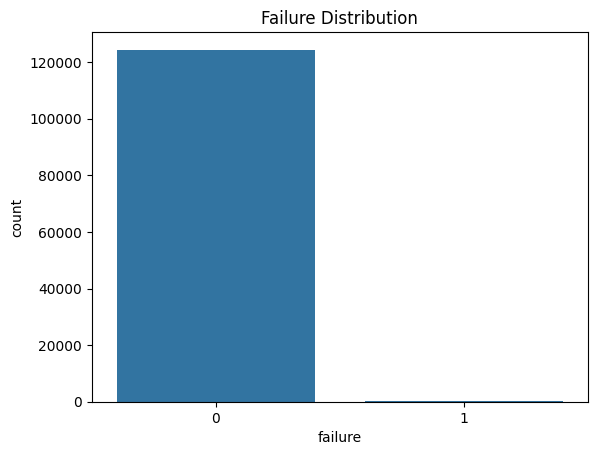

In [5]:
sns.countplot(x='failure', data=df)
plt.title("Failure Distribution")
plt.show()

In [6]:
df['timestamp'] = pd.to_datetime(df['date'])
df = df.sort_values(by='timestamp')

In [7]:
df_metrics_t = df[['timestamp','metric2','metric4','metric7','failure']]

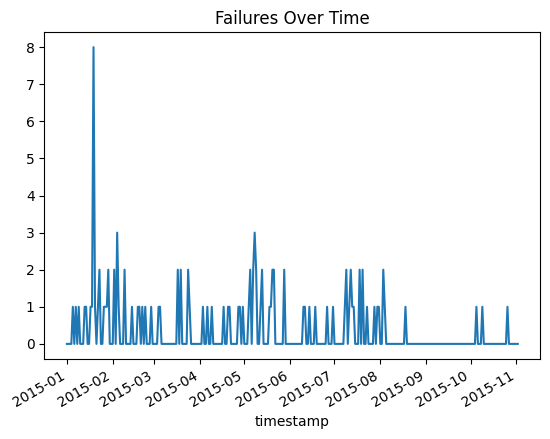

In [8]:
failures_over_time = df.groupby('timestamp')['failure'].sum()
failures_over_time.plot(kind='line', title='Failures Over Time')
plt.show()

In [9]:
total_per_device = df.groupby('device').size()
failures_per_device = df[df['failure'] == 1].groupby('device').size()

failure_rate_per_device = (failures_per_device / total_per_device).fillna(0)
failure_rate_per_device = failure_rate_per_device.sort_values(ascending=False)
print(failure_rate_per_device.head(10))

device
S1F0RRB1    0.200000
S1F11MB0    0.142857
S1F10E6M    0.142857
S1F0CTDN    0.142857
W1F0PNA5    0.111111
Z1F1AG5N    0.111111
W1F13SRV    0.076923
W1F03DP4    0.071429
W1F1230J    0.071429
W1F0T034    0.058824
dtype: float64


In [ ]:
print(df[df['device'] == 'S1F0RRB1'].groupby('failure').size())

failure
0    4
1    1
dtype: int64


### BAsic transformation
- transform tate to time
- create month and day columns
- split the mmachine gropus by the first 3 characters of the machine name (indication for the same group)

In [11]:
metric_columns = [col for col in df.columns if col.startswith('metric')]

In [12]:
time_diffs = df['timestamp'].diff().dropna()
print(f"Median spacing between readings: {time_diffs.median()}")

Median spacing between readings: 0 days 00:00:00


In [13]:
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df = df.sort_values(by='timestamp')

df['device_group_1'] = df['device'].str[:3]
df['device_group_2'] = df['device'].str[:4]

In [14]:
for i in range(len(metric_columns)):
    df[f'metric{i+1}'] = MinMaxScaler().fit_transform(np.array(df[f'metric{i+1}']).reshape(-1,1))

In [15]:
total_per_device_group = df.groupby('device_group_1').size()
failures_1_per_device_group = df[df['failure'] == 1].groupby('device_group_1').size()
failures_0_per_device_group = df[df['failure'] == 0].groupby('device_group_1').size()

summary = pd.DataFrame({
    'total_count': total_per_device_group,
    'count_failure_1': failures_1_per_device_group,
    'count_failure_0': failures_0_per_device_group,
})

summary['failure_rate'] = summary['count_failure_1'] / summary['total_count']
summary = summary.fillna(0).sort_values('failure_rate', ascending=False)
summary['failure_rate_pct'] = (summary['failure_rate'] * 100).round(2)

summary.head(10)

,total_count,count_failure_1,count_failure_0,failure_rate,failure_rate_pct
device_group_1,,,,,
W1F,43268,42,43226,0.000971,0.10
Z1F,26368,22,26346,0.000834,0.08
S1F,54858,42,54816,0.000766,0.08


In [16]:
total_per_device_group_2 = df.groupby('device_group_2').size()
failures_1_per_device_group_2 = df[df['failure'] == 1].groupby('device_group_2').size()
failures_0_per_device_group_2 = df[df['failure'] == 0].groupby('device_group_2').size()

summary = pd.DataFrame({
    'total_count': total_per_device_group_2,
    'count_failure_1': failures_1_per_device_group_2,
    'count_failure_0': failures_0_per_device_group_2,
})

summary['failure_rate'] = summary['count_failure_1'] / summary['total_count']
summary = summary.fillna(0).sort_values('failure_rate', ascending=False)
summary['failure_rate_pct'] = (summary['failure_rate'] * 100).round(2)

summary.head(10)

,total_count,count_failure_1,count_failure_0,failure_rate,failure_rate_pct
device_group_2,,,,,
Z1F1,7248,9.0,7239,0.001242,0.12
W1F0,23294,27.0,23267,0.001159,0.12
S1F0,33169,36.0,33133,0.001085,0.11
W1F1,19974,15.0,19959,0.000751,0.08
Z1F0,18869,13.0,18856,0.000689,0.07
S1F1,21689,6.0,21683,0.000277,0.03
Z1F2,251,0.0,251,0.000000,0.00


In [17]:
df_W1F0 = df[df['device_group_2'] == 'W1F0']
df_W1F0_q1 = df[
    (df['device_group_2'] == 'W1F0') &
    (df['timestamp'] >= '2015-01-01') &
    (df['timestamp'] <= '2015-04-30')
]


In [18]:
df_metrics_W1F0 = df_W1F0[['metric2','metric4','metric7','failure']]
df_metric_t_W1F0 = df_W1F0[['timestamp','metric2','metric4','metric7','failure']]

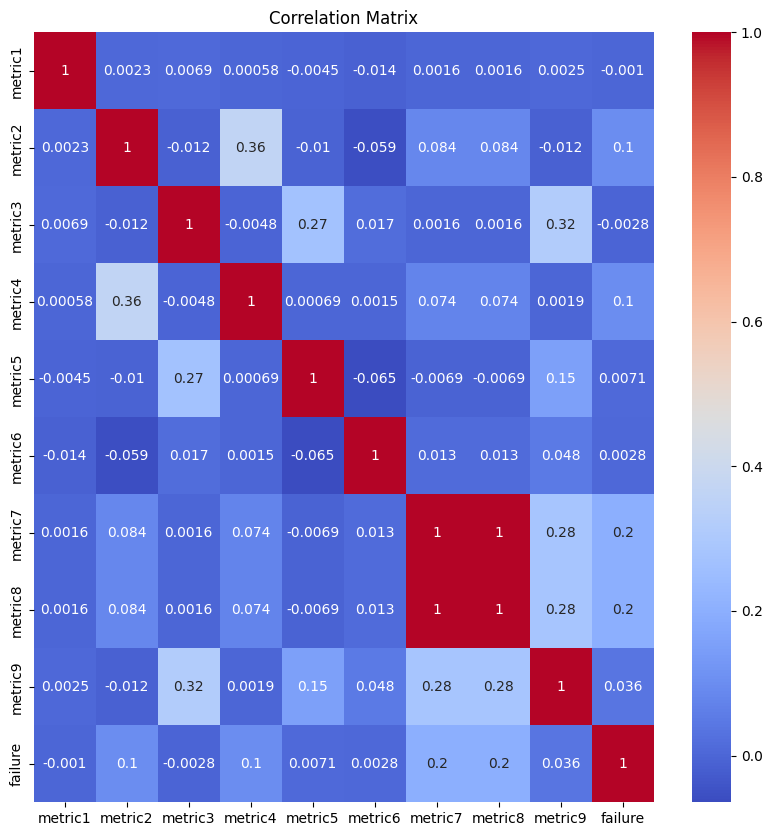

In [19]:
correlation(df_W1F0)

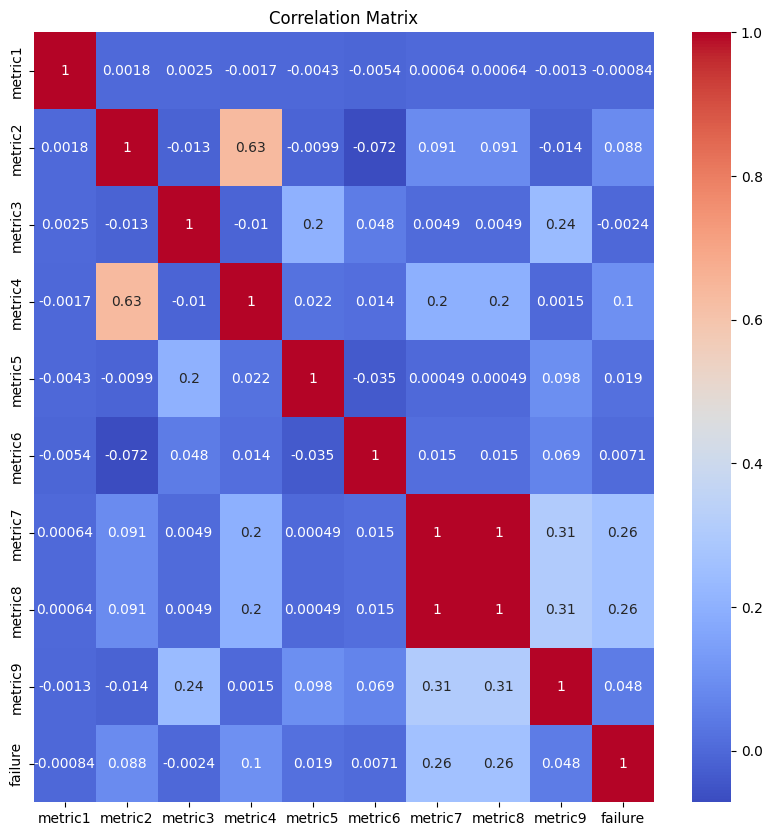

In [20]:
correlation(df_W1F0_q1)

### Analysis by metrics

In [21]:
#analysis_by_metrics(df,10)

#### Correlation Analysis
Action: Check for correlations between metrics, especially Metrics 2, 4, and 7. Correlated metrics might provide redundant information, while independent ones are likely more informative.
Goal: Identify pairs of highly correlated metrics (e.g., correlation > 0.8). You might combine or drop one of the pair in feature selection.

Result:
- meric 2, 4, 7 are confimed to have the highest correlation to failure
- metric 7, 8 are the same

In [22]:
#correlation(df)

In [23]:
#pairs(df,'failure')

In [26]:
df_export = df[
    [
        'timestamp',
        'metric2',
        'metric4',
        'metric7',
        'failure',
        'device_group_2',
    ]
]
df_export.to_parquet("predmain_sensor_data_clean.pqt")

In [24]:
def failures_over_time(df):    
    failures_over_time = df.groupby('timestamp')['failure'].sum()
    metric2_over_time = df.groupby('timestamp')['metric2'].sum()
    metric4_over_time = df.groupby('timestamp')['metric4'].sum()
    metric7_over_time = df.groupby('timestamp')['metric7'].sum()
    failures_over_time.plot(kind='line', title='Failures Over Time')
    metric2_over_time.plot(kind='line',color='red')
    metric4_over_time.plot(kind='line',color='orange')
    metric7_over_time.plot(kind='line',color='green')
    plt.show()

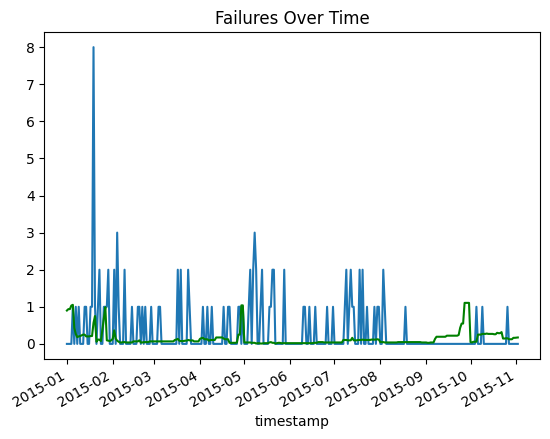

In [25]:
failures_over_time(df)

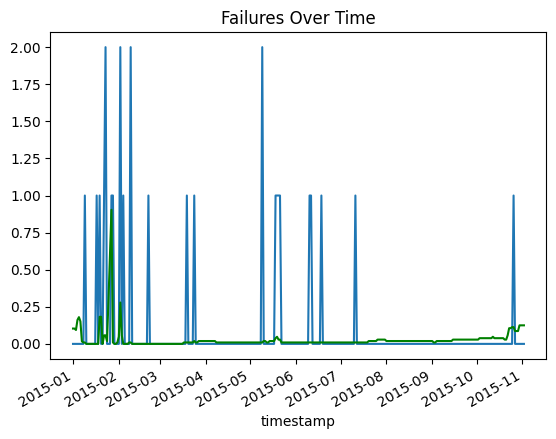

In [26]:
failures_over_time(df_W1F0)

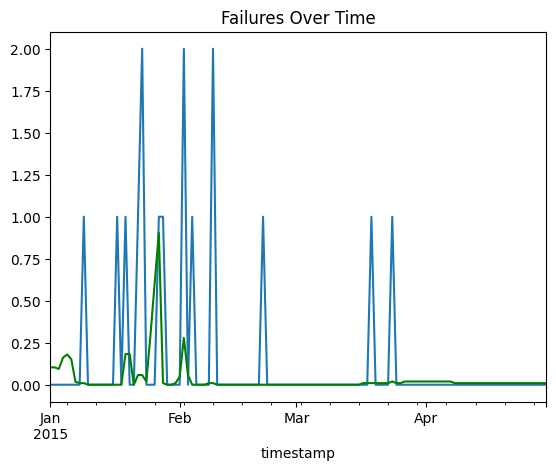

In [27]:
failures_over_time(df_W1F0_q1)

### Assessment of the models - Training data preparation
As we are bounded by the time series, the standard splits are not working. We can not use random split as we are looking for the patterns to failure sequentially driven by time.
We need a time series based test and train split. The baseline is the folloiwng article: https://medium.com/@mouadenna/time-series-splitting-techniques-ensuring-accurate-model-validation-5a3146db3088

In [28]:
X = df[['metric2', 'metric4', 'metric7']]
X_m2 = df[['metric2']]
X_m4 = df[['metric4']]
X_m7 = df[['metric7']]
y = df['failure']

In [29]:
X_W1F0 = df_W1F0[['metric2', 'metric4', 'metric7']]
y_W1F0 = df_W1F0['failure']

In [30]:
X_W1F0_t = df_W1F0[['timestamp','metric2', 'metric4', 'metric7']]
y_W1F0_t = df_W1F0['failure']

In [31]:
X_W1F0_q1 = df_W1F0[['metric2', 'metric4', 'metric7']]
y_W1F0_q1 = df_W1F0['failure']

In [32]:
def ohit_oversample(X_train, y_train, bins=200, random_state=None):
    """
    Perform OHIT oversampling on training data.
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series or np.array
        Training labels.
    bins : int
        Number of histogram bins to use per feature.
    random_state : int or None
        For reproducibility.

    Returns
    -------
    X_train_ohit : pd.DataFrame
        Training features with synthetic samples added.
    y_train_ohit : pd.Series
        Training labels with synthetic samples added.
    """
    rng = np.random.default_rng(random_state)

    # Combine features and labels for easier manipulation
    df_train = X_train.copy()
    df_train['failure'] = y_train

    # Separate minority and majority classes
    df_minority = df_train[df_train['failure'] == 1].copy()
    df_majority = df_train[df_train['failure'] == 0].copy()

    numeric_cols = df_minority.select_dtypes(include=[np.number]).columns.drop('failure')

    # 1) Build histograms for each numeric feature using minority class
    hist_params = {}
    for col in numeric_cols:
        data_col = df_minority[col].dropna().values
        counts, bin_edges = np.histogram(data_col, bins=bins)
        hist_params[col] = (counts, bin_edges)

    # 2) Decide how many synthetic samples to create
    minority_count = len(df_minority)
    majority_count = len(df_majority)
    desired_minority_count = majority_count
    num_new = max(0, desired_minority_count - minority_count)

    synthetic_rows = []

    # 3) Generate synthetic samples
    for _ in range(num_new):
        row_dict = {}
        for col in numeric_cols:
            counts, bin_edges = hist_params[col]
            total = counts.sum()
            if total == 0:
                val = rng.uniform(df_minority[col].min(), df_minority[col].max())
            else:
                bin_probs = counts / total
                chosen_bin = rng.choice(np.arange(len(counts)), p=bin_probs)
                left_edge = bin_edges[chosen_bin]
                right_edge = bin_edges[chosen_bin + 1]
                val = rng.uniform(left_edge, right_edge)
            row_dict[col] = val
        row_dict['failure'] = 1  # Set label to minority class
        synthetic_rows.append(row_dict)

    # Create synthetic DataFrame
    df_synthetic = pd.DataFrame(synthetic_rows)

    # Concatenate original and synthetic data
    df_combined = pd.concat([df_train, df_synthetic], ignore_index=True)

    # Separate features and labels
    X_train_ohit = df_combined.drop(columns=['failure'])
    y_train_ohit = df_combined['failure']

    return X_train_ohit, y_train_ohit

In [33]:
def timeseries_split(X,y):
    tscv = TimeSeriesSplit(n_splits=5)

    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    yield X_train, X_test, y_train, y_test

In [34]:
def timeseries_split_ohit(X, y, ohit_func, n_splits=5, random_state=42):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Oversample only the training portion
        X_train_ohit, y_train_ohit = ohit_func(X_train, y_train, bins=200, random_state=random_state)

        # Yield oversampled train, original test
        yield X_train_ohit, X_test, y_train_ohit, y_test

Oversampled train shape: (41460, 3) (41460,)
Test shape: (20749, 3) (20749,)


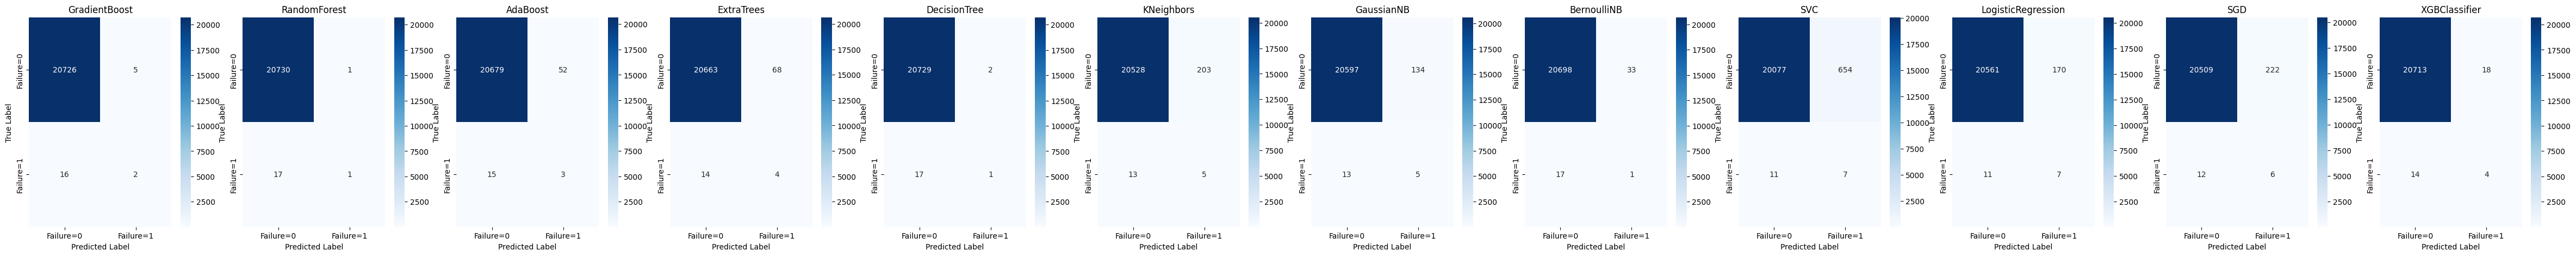

                    Accuracy Precision    Recall        F1
XGBClassifier       0.998458  0.181818  0.222222       0.2
GradientBoost       0.998988  0.285714  0.111111      0.16
RandomForest        0.999132       0.5  0.055556       0.1
DecisionTree        0.999084  0.333333  0.055556  0.095238
ExtraTrees          0.996048  0.055556  0.222222  0.088889
AdaBoost            0.996771  0.054545  0.166667  0.082192
LogisticRegression  0.991277  0.039548  0.388889  0.071795
GaussianNB          0.992915  0.035971  0.277778  0.063694
SGD                 0.988722  0.026316  0.333333   0.04878
KNeighbors           0.98959  0.024038  0.277778  0.044248
BernoulliNB          0.99759  0.029412  0.055556  0.038462
SVC                  0.96795   0.01059  0.388889  0.020619
Oversampled train shape: (82922, 3) (82922,)
Test shape: (20749, 3) (20749,)


In [ ]:
for X_tr_ohit, X_te, y_tr_ohit, y_te in timeseries_split_ohit(X, y, ohit_oversample, n_splits=5):
    print("Oversampled train shape:", X_tr_ohit.shape, y_tr_ohit.shape)
    print("Test shape:", X_te.shape, y_te.shape)
    model_test(X_tr_ohit, X_te, y_tr_ohit, y_te)